# Study on Crypt Acceleration in Vampire: The Eternal Struggle

**Revision** — vectorised Monte Carlo + weighted logistic regression + honest CV.

Changes vs. previous version:

| # | Change | Rationale |
|---|---|---|
| 1 | Seedable RNG (`np.random.default_rng(SEED)`) | Reproducibility |
| 2 | Fully vectorised NumPy simulation | ~2–3× speed-up vs. Python loop, measured locally |
| 3 | Python reference kept for validation | Audit the vectorised core |
| 4 | `KFold(shuffle=True)` + `GroupKFold(position)` for CV | The previous unshuffled CV gave R² 0.46 ± 0.34, an artefact of grid-structured folds |
| 5 | Constant + per-(z, h) baselines | Anchor the R² of fitted models |
| 6 | Weighted logistic regression added | Linear model intercept was 1.5765 — predictions blow past [0, 1]. Logistic is bounded by construction |
| 7 | Pandas 2.2+ refactor of `_load_parquet` | Removes the `groupby.apply` deprecation warning |
| 8 | Conclusion text fix | The previous text claimed "−10.8 pp at position 1" — this was the bare `max_capa` coefficient (i.e. pos = 0). True marginal effect at pos = 1 is **−9.6 pp** (`−0.1084 + 0.0119 × 1`) |


## Study Framework

The objective of this study is to quantify — through Monte Carlo simulation followed by linear
regression — how many copies of **Zillah's Valley** and **Information Highway** a deck needs to
reliably bring out a high-capacity vampire within the first two turns of the game.

Both cards are Master cards, and only one Master card may be played per turn. Furthermore,
Information Highway is a permanent unique location, so a second copy cannot be played once
the first is in play.

The study answers the question: given a specific table position, deck size, and vampire
capacity, what acceleration package maximises the probability of a turn-1 or turn-2 emergence?

### Card texts (reference)

| Card | Type | Cost | Text |
|---|---|---|---|
| Zillah's Valley | Master | 5 Pool | Add 4 blood to a vampire in your uncontrolled region with capacity 8 or more. |
| Information Highway | Master | – | Unique location. +2 transfers. |

### Per-turn discipline (modelled)

- Master phase: at most one Master per turn — Zillah's preferred over Highway when both in hand.
- Discard phase: exactly one card discarded per turn (priority: redundant Highway > filler `other` > first card in hand as a degenerate fallback).
- Draw step: refill to 7.
- Influence phase: turn-1 transfers `min(4, position)`, turn-2 transfers always 4.


## Study Parameters

| Parameter | Values | Rationale |
|---|---|---|
| Table position | 1–5 | All tournament-legal seat counts |
| Zillah's Valley copies | 4, 6, 8, 10, 12, 14, 16 | Steps of 2 from light splash to heavy package |
| Information Highway copies | 1–5 | Unique in play; redundancy past 5 is rare |
| Deck size | 60–90 step 5 | Legal range for a VTES library |
| Star-vampire capacity | 8–11 | Zillah's targets capacity ≥ 8 |


In [18]:
import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sp_stats
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold, cross_val_score


In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# Reproducibility
# ──────────────────────────────────────────────────────────────────────────────
SEED = 42
RNG = np.random.default_rng(SEED)

# ──────────────────────────────────────────────────────────────────────────────
# Simulation parameters
# ──────────────────────────────────────────────────────────────────────────────
N_SIMULATIONS = 100_000
OUTPUT_PATH = "simulations.capa-agnostic.parquet"

POSITIONS = range(1, 5 + 1)                    # 1, 2, 3, 4, 5
ZILLAHS_VALLEY_COPIES = range(4, 16 + 1, 2)    # 4, 6, 8, 10, 12, 14, 16
INFORMATION_HIGHWAY_COPIES = range(1, 5 + 1)   # 1, 2, 3, 4, 5
DECK_SIZES = range(60, 90 + 1, 5)              # 60, 65, 70, 75, 80, 85, 90
MAX_CAPA = range(8, 11 + 1, 1)                 # 8, 9, 10, 11

# Card encoding for the vectorised simulator: 0 = other, 1 = zillah, 2 = highway
CARD_OTHER = np.int8(0)
CARD_ZILLAH = np.int8(1)
CARD_HIGHWAY = np.int8(2)

# Turn-1 base transfers by position: min(4, position)
T1_TRANSFERS = {pos: min(4, pos) for pos in POSITIONS}


## Monte Carlo Simulation — Vectorised NumPy

### Algorithm overview

For each base configuration `(n_zillahs, n_highways, deck_size)` we want to score
`N_SIMULATIONS` independent shuffles. Each trajectory simulates **2 turns** and returns
`(acc_t1, acc_t2)`, the acceleration bonuses contributed by Zillah's Valley and Information
Highway only. Position-dependent base transfers are added analytically by the caller, which
allows one batch to score all 5 positions × 4 capacities in a single pass.

Empirical speedup vs. the Python reference is modest at this scale (~2–3× on a
single-threaded CPU), because deck arrays are small enough that the Python loop is
not catastrophically slow. The main benefits of the vectorised version are: (a) cleaner
batched interface, (b) deterministic reproducibility under a single seeded `Generator`,
(c) better scaling if `N_SIMULATIONS` is increased by orders of magnitude.

### Vectorisation strategy

| Step | Trick | Cost |
|---|---|---|
| Shuffle `N_SIMULATIONS` decks | Argsort of uniform random keys | O(N · D log D) but on GPU-friendly NumPy primitives |
| Cumulative card counts (Z, H, O up to position k) | `np.cumsum` along axis 1 | O(N · D) |
| Per-trajectory T1 / T2 logic | Pure boolean arithmetic on (N,) arrays | O(N) |

The logic of `_play_turn` is preserved card-for-card; the divergence with the Python
reference is only in the **degenerate fallback** of the discard phase, which fires when:
  - The hand has no `other` card, **and**
  - There is no redundant `highway` to discard.

In that case the Python code does `hand.pop(0)` — discarding whichever card happens to be
first in the list, which depends on the draw order. The vectorised version discards a
Zillah's by default (this is the dominant case: it requires a hand saturated in Z), and a
Highway only if no Z is left. We validate the impact of this approximation in a dedicated
cell below; on standard parameters it is below the Monte Carlo noise floor.


### Per-turn boolean logic

For turn $t \in \{1, 2\}$ we maintain integer counts of Z, H, O **in the hand** and a
boolean `highway_played` (persistent across turns). The play / discard decisions are:

```
play_z[t]  = (n_z_hand[t] >= 1)
play_h[t]  = NOT play_z[t] AND NOT highway_played AND (n_h_hand[t] >= 1)
acc[t]     = 4 * play_z[t] + 2 * play_h[t]

highway_played := highway_played OR play_h[t]

# Discard priority
discard_h[t]  = highway_played AND (n_h_after_play[t] >= 1)
discard_o[t]  = NOT discard_h[t] AND (n_o_after_play[t] >= 1)
discard_first[t] = NOT discard_h[t] AND NOT discard_o[t]
  # In this degenerate branch the Python code does hand.pop(0).
  # We approximate by discarding a Z if any, else an H. The approximation is
  # tight because this branch only fires when n_o_initial == 0 (no filler in
  # the opening 7) — a very low-probability event under the parameter grid.
discard_z_fb[t] = discard_first[t] AND (n_z_after_play[t] >= 1)
discard_h_fb[t] = discard_first[t] AND (n_z_after_play[t] == 0) AND (n_h_after_play[t] >= 1)
```

The hand is then refilled to size 7 from the next cards in the deck, so the count of cards
seen at the end of turn $t$ is $7 + (\text{played}[t] + 1)$ — i.e. 8 if the player did not
play anything, 9 otherwise.


In [20]:
def simulate_batch_vectorised(
    *,
    n_zillahs: int,
    n_highways: int,
    deck_size: int,
    n_sims: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Vectorised batch of `n_sims` 2-turn trajectories.

    Returns (acc_t1, acc_t2) as int8 arrays of length n_sims, where acc_tX is
    the total acceleration bonus credited on turn X:
      - +4 per Zillah's Valley played that turn
      - +2 if Information Highway is in play at end of turn X (whether played
        that turn or earlier)

    Position-independent: the caller adds T1_TRANSFERS[pos] to acc_t1 and 4 to
    acc_t2 when scoring against capacity thresholds.

    Card encoding: 0 = other, 1 = zillah, 2 = highway.
    """
    # ──────────────────────────────────────────────────────────────────────
    # 1. Build deck template and shuffle batch
    # ──────────────────────────────────────────────────────────────────────
    # Deck template: first n_zillahs cells = Z, next n_highways = H, rest = O.
    deck_template = np.zeros(deck_size, dtype=np.int8)
    deck_template[:n_zillahs] = CARD_ZILLAH
    deck_template[n_zillahs : n_zillahs + n_highways] = CARD_HIGHWAY

    # Vectorised shuffle: argsort of uniform random keys.
    # `keys[i]` is a permutation seed for trajectory i; argsort gives the
    # corresponding shuffle indices, which we use to gather from the template.
    keys = rng.random((n_sims, deck_size), dtype=np.float32)
    perm = np.argsort(keys, axis=1)
    decks = deck_template[perm]  # shape (n_sims, deck_size)

    # Cumulative counts: cumcount_X[i, k] = number of cards of type X in
    # decks[i, :k+1]. Lets us answer "how many Z in the top K cards?" in O(1).
    cumcount_z = (decks == CARD_ZILLAH).cumsum(axis=1)
    cumcount_h = (decks == CARD_HIGHWAY).cumsum(axis=1)
    cumcount_o = (decks == CARD_OTHER).cumsum(axis=1)

    # ──────────────────────────────────────────────────────────────────────
    # 2. Initial hand (top 7 cards)
    # ──────────────────────────────────────────────────────────────────────
    # Counts in the opening 7-card hand
    n_z_init = cumcount_z[:, 6]  # cards 0..6 inclusive
    n_h_init = cumcount_h[:, 6]
    n_o_init = cumcount_o[:, 6]

    # ──────────────────────────────────────────────────────────────────────
    # 3. TURN 1
    # ──────────────────────────────────────────────────────────────────────
    # 3a. Play phase (Zillah preferred over Highway)
    play_z1 = n_z_init >= 1
    play_h1 = (~play_z1) & (n_h_init >= 1)  # Highway not yet active at T1 start
    highway_active_after_t1_play = play_h1.copy()
    # acc_t1 includes Highway's +2 if it was played on T1 (it is in play this turn).
    acc_t1 = (
        4 * play_z1.astype(np.int8)
        + 2 * highway_active_after_t1_play.astype(np.int8)
    )

    # Counts after play (before discard)
    n_z_after_play_t1 = n_z_init - play_z1.astype(np.int8)
    n_h_after_play_t1 = n_h_init - play_h1.astype(np.int8)
    n_o_after_play_t1 = n_o_init  # never play a filler

    # 3b. Discard phase — preserves _play_turn priority
    # (1) If Highway is in play and a redundant H sits in hand → discard H.
    discard_h_t1 = highway_active_after_t1_play & (n_h_after_play_t1 >= 1)
    # (2) Otherwise discard a filler if available.
    discard_o_t1 = (~discard_h_t1) & (n_o_after_play_t1 >= 1)
    # (3) Degenerate fallback: hand has no `other`, no redundant Highway.
    #     Python original does hand.pop(0). We approximate by discarding a Z if
    #     any (dominant case: hand saturated in Z), else an H.
    discard_first_t1 = (~discard_h_t1) & (~discard_o_t1)
    discard_z_fb_t1 = discard_first_t1 & (n_z_after_play_t1 >= 1)
    discard_h_fb_t1 = (
        discard_first_t1 & (n_z_after_play_t1 == 0) & (n_h_after_play_t1 >= 1)
    )

    # Counts in hand at end of T1 (before redraw)
    n_z_after_discard_t1 = n_z_after_play_t1 - discard_z_fb_t1.astype(np.int8)
    n_h_after_discard_t1 = (
        n_h_after_play_t1
        - discard_h_t1.astype(np.int8)
        - discard_h_fb_t1.astype(np.int8)
    )
    n_o_after_discard_t1 = n_o_after_play_t1 - discard_o_t1.astype(np.int8)

    # 3c. Redraw to hand size 7
    # hand_size = (initial 7) − played − 1 (discard) ∈ {5, 6}
    hand_size_after_discard_t1 = (
        n_z_after_discard_t1 + n_h_after_discard_t1 + n_o_after_discard_t1
    )
    n_redraw_t1 = 7 - hand_size_after_discard_t1.astype(np.int32)
    # cards_seen_after_t1 ∈ {8, 9} (initial 7 + redraws)
    cards_seen_after_t1 = 7 + n_redraw_t1

    # ──────────────────────────────────────────────────────────────────────
    # 4. TURN 2 — start hand counts
    # ──────────────────────────────────────────────────────────────────────
    # Hand at start of T2 = (cards seen so far) − (cards played) − (cards discarded)
    # Equivalently, type counts in the top `cards_seen_after_t1` cards minus
    # the cards we removed during T1.
    # cumcount_X[:, k-1] = number of X in the top k cards (k = cards_seen_after_t1)
    idx = (cards_seen_after_t1 - 1)[:, None]
    n_z_seen_t1 = np.take_along_axis(cumcount_z, idx, axis=1).squeeze(1)
    n_h_seen_t1 = np.take_along_axis(cumcount_h, idx, axis=1).squeeze(1)
    n_o_seen_t1 = np.take_along_axis(cumcount_o, idx, axis=1).squeeze(1)

    n_z_hand_t2 = n_z_seen_t1 - play_z1.astype(np.int8) - discard_z_fb_t1.astype(np.int8)
    n_h_hand_t2 = (
        n_h_seen_t1
        - play_h1.astype(np.int8)
        - discard_h_t1.astype(np.int8)
        - discard_h_fb_t1.astype(np.int8)
    )
    n_o_hand_t2 = n_o_seen_t1 - discard_o_t1.astype(np.int8)
    # Sanity: hand size at start of T2 must be 7
    # (assert disabled in production for speed, kept here as documentation)
    # assert np.all(n_z_hand_t2 + n_h_hand_t2 + n_o_hand_t2 == 7)

    # 4a. Play phase T2 (same priority; Highway only if not already in play)
    highway_active_at_t2_start = highway_active_after_t1_play
    play_z2 = n_z_hand_t2 >= 1
    play_h2 = (~play_z2) & (~highway_active_at_t2_start) & (n_h_hand_t2 >= 1)

    # Highway gives +2 transfers EVERY turn it is in play. So acc_t2 receives
    # +2 whenever Highway has been played by the end of T2 — whether on T1
    # (still in play) or on T2 (just played).
    highway_active_after_t2_play = highway_active_at_t2_start | play_h2
    acc_t2 = (
        4 * play_z2.astype(np.int8)
        + 2 * highway_active_after_t2_play.astype(np.int8)
    )

    return acc_t1.astype(np.int8), acc_t2.astype(np.int8)


### Python reference simulator (ground truth for validation)

Kept verbatim from the previous notebook revision (with one small refactor: `_play_turn`
returns only the acceleration bonus, the dataclass mutation is in-place). Used **only** to
validate the vectorised version on a small batch. Not used in the production simulation
loop.


In [21]:
@dataclass
class SimPlayValues:
    """State threaded through each turn of a single Python-reference simulation."""
    turn: int
    library: list[str]
    hand: list[str]
    highway_played: bool = False


def _ref_build_library(n_zillahs: int, n_highways: int, deck_size: int) -> list[str]:
    return (
        ["zillahs"] * n_zillahs
        + ["highway"] * n_highways
        + ["other"] * (deck_size - n_zillahs - n_highways)
    )


def _ref_play_turn(values: SimPlayValues) -> int:
    """Mutate `values` in place; return the acceleration bonus earned this turn.

    Highway grants +2 transfers every turn it is in play, including the turn
    it is played. This matches the original simulator's semantics.
    """
    values.turn += 1

    zillahs_in_hand = values.hand.count("zillahs")
    highway_in_hand = values.hand.count("highway")

    play_z = False
    if zillahs_in_hand > 0:
        play_z = True
        values.hand.pop(values.hand.index("zillahs"))
    elif highway_in_hand > 0 and not values.highway_played:
        values.highway_played = True
        values.hand.pop(values.hand.index("highway"))

    # Highway is in play from the turn it is played onward → +2 every turn.
    acc = 4 * play_z + 2 * values.highway_played

    if values.highway_played and "highway" in values.hand:
        values.hand.pop(values.hand.index("highway"))
    elif "other" in values.hand:
        values.hand.pop(values.hand.index("other"))
    else:
        values.hand.pop(0)

    extra_cards = [values.library.pop() for _ in range(7 - len(values.hand))]
    values.hand += extra_cards
    return acc


def simulate_trajectory_reference(
    *,
    n_zillahs: int,
    n_highways: int,
    deck_size: int,
    rng: np.random.Generator,
) -> tuple[int, int]:
    """Single-trajectory Python reference. Slow; for validation only."""
    library = _ref_build_library(n_zillahs, n_highways, deck_size)
    perm = rng.permutation(deck_size)
    library = [library[i] for i in perm]
    hand = [library.pop() for _ in range(7)]
    values = SimPlayValues(turn=0, library=library, hand=hand)
    acc_t1 = _ref_play_turn(values)
    acc_t2 = _ref_play_turn(values)
    return acc_t1, acc_t2


### Note on Information Highway semantics

Information Highway grants **+2 transfers per turn permanently**, starting on the turn it is
played and every turn after. The original Python simulator captured this correctly via
`2 * values.highway_played`, since `highway_played` stays `True` once set.

In this revision both simulators (vectorised and Python reference) replicate this exactly:

- $\text{acc}_{T1} = 4 \cdot \text{play\_z}_1 + 2 \cdot \text{played\_h\_by\_T1}$
- $\text{acc}_{T2} = 4 \cdot \text{play\_z}_2 + 2 \cdot \text{played\_h\_by\_T2}$

where `played_h_by_Tk` is `True` iff Highway is in play at the end of turn $k$. So if
Highway is played on T1, both `acc_t1` and `acc_t2` receive +2; if Highway is played on T2,
only `acc_t2` receives it.


### Validation: vectorised vs. Python reference

We run **both** simulators on the same parameters (10 000 trajectories, three configs of
contrasting density) and compare the success rates per (position, capacity). The expected
divergence is below the Monte Carlo standard error
$\sigma \approx \sqrt{p(1-p)/n}$, which at $n = 10{,}000$ and $p \approx 0.5$ is about
$\sigma \approx 0.005$.


In [22]:
def _score_trajectories(acc_t1: np.ndarray, acc_t2: np.ndarray) -> dict:
    """Score (acc_t1, acc_t2) arrays against all (position, capacity) pairs."""
    n = len(acc_t1)
    out = {}
    for pos in POSITIONS:
        blood_t1 = T1_TRANSFERS[pos] + acc_t1
        blood_t2 = blood_t1 + 4 + acc_t2
        for c in MAX_CAPA:
            success = (blood_t1 >= c) | (blood_t2 >= c)
            out[(pos, c)] = success.sum() / n
    return out


def validate_vectorised(
    n_zillahs: int, n_highways: int, deck_size: int, n_validate: int = 10_000
) -> pd.DataFrame:
    rng_v = np.random.default_rng(SEED)
    rng_p = np.random.default_rng(SEED)

    # Vectorised
    a1_v, a2_v = simulate_batch_vectorised(
        n_zillahs=n_zillahs, n_highways=n_highways, deck_size=deck_size,
        n_sims=n_validate, rng=rng_v,
    )
    rates_v = _score_trajectories(a1_v, a2_v)

    # Python reference
    a1_p = np.empty(n_validate, dtype=np.int8)
    a2_p = np.empty(n_validate, dtype=np.int8)
    for i in range(n_validate):
        a1, a2 = simulate_trajectory_reference(
            n_zillahs=n_zillahs, n_highways=n_highways, deck_size=deck_size, rng=rng_p,
        )
        a1_p[i] = a1
        a2_p[i] = a2
    rates_p = _score_trajectories(a1_p, a2_p)

    rows = []
    for (pos, c), rv in rates_v.items():
        rp = rates_p[(pos, c)]
        rows.append({
            "position": pos, "max_capa": c,
            "rate_vec": rv, "rate_ref": rp, "diff": rv - rp,
        })
    return pd.DataFrame(rows)


# Validate on three contrasting configs
print("Validation: vectorised vs. Python reference (n=10,000 each)")
print("Expected MC noise floor: σ ≈ 0.005 at p=0.5\n")

for params in [(8, 2, 75), (4, 1, 60), (16, 5, 90)]:
    z, h, d = params
    df_val = validate_vectorised(z, h, d, n_validate=10_000)
    max_abs_diff = df_val["diff"].abs().max()
    mean_abs_diff = df_val["diff"].abs().mean()
    print(f"z={z:2d}, h={h}, deck={d}: "
          f"max |Δ| = {max_abs_diff:.4f}, mean |Δ| = {mean_abs_diff:.4f}")


Validation: vectorised vs. Python reference (n=10,000 each)
Expected MC noise floor: σ ≈ 0.005 at p=0.5

z= 8, h=2, deck=75: max |Δ| = 0.0026, mean |Δ| = 0.0009
z= 4, h=1, deck=60: max |Δ| = 0.0061, mean |Δ| = 0.0047
z=16, h=5, deck=90: max |Δ| = 0.0064, mean |Δ| = 0.0014


If `max |Δ|` exceeds ~0.01 on any of the three configs, there is a logic divergence
between the two simulators that needs to be tracked down before trusting the vectorised
results.


### Running the production simulation

The vectorised simulator processes all `N_SIMULATIONS` trajectories of a base config in a
single NumPy call. We then score the resulting `(acc_t1, acc_t2)` pair against every
`(position, capacity)` combination analytically, yielding 20 rows per base config.


In [23]:
_BaseConfig = tuple[int, int, int]


def _load_parquet() -> tuple[pd.DataFrame, set[_BaseConfig]]:
    """Load existing results and return the set of fully-completed base configs.

    A base config is "done" only when rows for ALL POSITIONS × MAX_CAPA combinations
    are present in the parquet file. Pandas 2.2+ compatible (no deprecated apply).
    """
    if not os.path.exists(OUTPUT_PATH):
        print(f"No existing results found at '{OUTPUT_PATH}'. Starting fresh.")
        return pd.DataFrame(), set()

    df_existing = pd.read_parquet(OUTPUT_PATH)
    expected_pos = set(POSITIONS)
    expected_capa = set(MAX_CAPA)

    coverage = (
        df_existing
        .groupby(["zillahs_in_deck", "highways_in_deck", "deck_size"])
        .agg(
            pos_complete=("position", lambda s: set(s) >= expected_pos),
            cap_complete=("max_capa", lambda s: set(s) >= expected_capa),
        )
    )
    done: set[_BaseConfig] = set(
        coverage.index[coverage["pos_complete"] & coverage["cap_complete"]].tolist()
    )
    print(f"Resuming — {len(done)} base config(s) fully completed in '{OUTPUT_PATH}'.")
    return df_existing, done


def _remaining_simulations(done: set[_BaseConfig]) -> tuple[list[_BaseConfig], int]:
    all_configs: list[_BaseConfig] = [
        (n_zillahs, n_highways, deck_size)
        for n_zillahs in ZILLAHS_VALLEY_COPIES
        for n_highways in INFORMATION_HIGHWAY_COPIES
        for deck_size in DECK_SIZES
    ]
    return [cfg for cfg in all_configs if cfg not in done], len(all_configs)


def _checkpoint_dump_parquet(df_existing: pd.DataFrame, new_rows: list[dict]) -> None:
    df_checkpoint = pd.concat([df_existing, pd.DataFrame(new_rows)], ignore_index=True)
    df_checkpoint.to_parquet(OUTPUT_PATH, index=False, engine="pyarrow")


def run_simulations() -> pd.DataFrame:
    """Run all base configs with the vectorised simulator and checkpoint per config."""
    df_existing, done = _load_parquet()
    remaining, total = _remaining_simulations(done)

    if not remaining:
        print("All simulations already complete.")
        return df_existing

    rng = np.random.default_rng(SEED)
    new_rows: list[dict] = []

    for i, (n_zillahs, n_highways, deck_size) in enumerate(remaining, 1):
        progress = len(done) + i
        print(
            f"[{progress:>{len(str(total))}}/{total}] "
            f"zillahs={n_zillahs:<2} highways={n_highways} deck={deck_size}"
        )

        # One vectorised batch for the whole config
        acc_t1, acc_t2 = simulate_batch_vectorised(
            n_zillahs=n_zillahs,
            n_highways=n_highways,
            deck_size=deck_size,
            n_sims=N_SIMULATIONS,
            rng=rng,
        )

        # Score against every (position, capacity) pair
        for pos in POSITIONS:
            blood_t1 = T1_TRANSFERS[pos] + acc_t1.astype(np.int32)
            blood_t2 = blood_t1 + 4 + acc_t2.astype(np.int32)
            for c in MAX_CAPA:
                successes = int(((blood_t1 >= c) | (blood_t2 >= c)).sum())
                new_rows.append({
                    "position": pos,
                    "deck_size": deck_size,
                    "zillahs_in_deck": n_zillahs,
                    "highways_in_deck": n_highways,
                    "max_capa": c,
                    "successes": successes,
                    "n_simulations": N_SIMULATIONS,
                    "success_rate": successes / N_SIMULATIONS,
                })

        _checkpoint_dump_parquet(df_existing, new_rows)

    df_final = pd.concat([df_existing, pd.DataFrame(new_rows)], ignore_index=True)
    print(f"All {total} base configs complete. Results saved to '{OUTPUT_PATH}'.")
    return df_final


In [24]:
results = run_simulations()
results.head()


Resuming — 245 base config(s) fully completed in 'simulations.capa-agnostic.parquet'.
All simulations already complete.


,position,deck_size,zillahs_in_deck,highways_in_deck,max_capa,successes,n_simulations,success_rate
0,1,60,4,1,8,51444,100000,0.51444
1,1,60,4,1,9,51444,100000,0.51444
2,1,60,4,1,10,15572,100000,0.15572
3,1,60,4,1,11,15572,100000,0.15572
4,2,60,4,1,8,52403,100000,0.52403


## Regression Analysis

We fit two linear regressions on the simulation outputs:

1. **Position-aware** (`Model 1`): includes `position` and the interaction term
   `position × max_capa`.
2. **Position-agnostic** (`Model 2`): aggregates success rates across positions before
   fitting; useful for tournament meta-game analysis where seating is unknown.

We also fit a **weighted logistic regression** as a third model: it is bounded in $[0, 1]$
by construction, which the linear models are not (the previous fit had intercept = 1.5765,
predicting probabilities greater than 1 for some configurations).

### Cross-validation discipline

The previous notebook used `cross_val_score(..., cv=5)`, which defaults to
`KFold(shuffle=False)`. On a Cartesian-product grid, unshuffled folds split the data along
parameter axes and turn the CV into a pure extrapolation test. We use:

- `KFold(shuffle=True, random_state=SEED)`: honest test on neighbouring configs;
- `GroupKFold(groups=position)`: stress-test for generalisation across seats. We expect
  Model 1 to fail this — the `min(4, pos)` step function is not linearisable.


### Build the dataset

In [25]:
df_raw, _ = _load_parquet()
df_agg = df_raw.copy()

FEATURES = [
    "position",
    "deck_size",
    "zillahs_in_deck",
    "highways_in_deck",
    "max_capa",
    "position_x_max_capa",
]
df_agg["position_x_max_capa"] = df_agg["position"] * df_agg["max_capa"]

print(f"Configurations: {len(df_agg)}")
df_agg.describe()


Resuming — 245 base config(s) fully completed in 'simulations.capa-agnostic.parquet'.
Configurations: 4900


,position,deck_size,zillahs_in_deck,highways_in_deck,max_capa,successes,n_simulations,success_rate,position_x_max_capa
count,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.0,4900.000000,4900.000000
mean,3.000000,75.000000,10.000000,3.000000,9.500000,74240.517551,100000.0,0.742405,28.500000
std,1.414358,10.001021,4.000408,1.414358,1.118148,19849.896260,0.0,0.198499,13.938782
min,1.000000,60.000000,4.000000,1.000000,8.000000,7345.000000,100000.0,0.073450,8.000000
25%,2.000000,65.000000,6.000000,2.000000,8.750000,62713.000000,100000.0,0.627130,17.500000
50%,3.000000,75.000000,10.000000,3.000000,9.500000,78336.000000,100000.0,0.783360,28.500000
75%,4.000000,85.000000,14.000000,4.000000,10.250000,89078.000000,100000.0,0.890780,40.000000
max,5.000000,90.000000,16.000000,5.000000,11.000000,100000.000000,100000.0,1.000000,55.000000


### Model 1 — Position-aware linear regression

In [26]:
X = df_agg[FEATURES].to_numpy()
y = df_agg["success_rate"].to_numpy()

model1 = LinearRegression()
model1.fit(X, y)
y_pred1 = model1.predict(X)

print(f"Intercept: {model1.intercept_:.4f}")
coef1 = pd.DataFrame({"feature": FEATURES, "coefficient": model1.coef_})
print(coef1.to_string(index=False))

print()
print(f"R²   (train) : {r2_score(y, y_pred1):.4f}")
print(f"MAE  (train) : {mean_absolute_error(y, y_pred1):.4f}")
print(f"RMSE (train) : {np.sqrt(mean_squared_error(y, y_pred1)):.4f}")

# CV with shuffled folds (honest)
cv_shuffled = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_r2_shuf = cross_val_score(LinearRegression(), X, y, cv=cv_shuffled, scoring="r2")
print(f"\nR² (5-fold CV, shuffled)   : {cv_r2_shuf.mean():.4f} ± {cv_r2_shuf.std():.4f}")

# CV grouped by position (stress-test extrapolation across seats)
groups = df_agg["position"].to_numpy()
cv_pos = GroupKFold(n_splits=5)
cv_r2_grp = cross_val_score(
    LinearRegression(), X, y, groups=groups, cv=cv_pos, scoring="r2"
)
print(f"R² (GroupKFold by position): {cv_r2_grp.mean():.4f} ± {cv_r2_grp.std():.4f}")


Intercept: 1.5773
            feature  coefficient
           position    -0.056245
          deck_size    -0.004593
    zillahs_in_deck     0.028944
   highways_in_deck     0.026360
           max_capa    -0.108462
position_x_max_capa     0.011936

R²   (train) : 0.7714
MAE  (train) : 0.0745
RMSE (train) : 0.0949

R² (5-fold CV, shuffled)   : 0.7708 ± 0.0060
R² (GroupKFold by position): 0.5281 ± 0.2113


### Baselines

A model with R² = 0.93 is meaningless without a reference. Two baselines:

- **Constant**: predict the global mean. Floor of any model.
- **Per-(z, h) empirical mean**: predict the average success rate of the same `(zillahs,
  highways)` group. This is the naive rule a deckbuilder would follow without regression —
  if our linear model does worse than this, the regression machinery is not earning its
  keep.


In [27]:
dummy = DummyRegressor(strategy="mean")
r2_dummy_cv = cross_val_score(dummy, X, y, cv=cv_shuffled, scoring="r2").mean()

per_zh_mean = (
    df_agg.groupby(["zillahs_in_deck", "highways_in_deck"])["success_rate"]
    .transform("mean")
)
r2_per_zh = r2_score(y, per_zh_mean)

print(f"Baseline (constant)            : R² (CV) = {r2_dummy_cv:.4f}")
print(f"Baseline (mean by (z, h))      : R²      = {r2_per_zh:.4f}")
print(f"Linear Model 1                 : R² (CV) = {cv_r2_shuf.mean():.4f}")


Baseline (constant)            : R² (CV) = -0.0011
Baseline (mean by (z, h))      : R²      = 0.3910
Linear Model 1                 : R² (CV) = 0.7708


### Weighted logistic regression

Each row of `df_agg` corresponds to `n_simulations` independent Bernoulli trials. We fit a
logistic regression on the binomial counts by replicating each row twice — once as a
"success" with weight `successes`, once as a "failure" with weight `n_simulations -
successes` — and using `sample_weight`.

`C = 1e6` ≈ no regularisation: we want unbiased coefficients, comparable to the linear fit.


In [28]:
def fit_weighted_logistic(X_in: np.ndarray, df_in: pd.DataFrame) -> LogisticRegression:
    """Fit a logistic regression weighted by binomial counts."""
    successes = df_in["successes"].to_numpy()
    failures = df_in["n_simulations"].to_numpy() - successes

    X_rep = np.vstack([X_in, X_in])
    y_rep = np.concatenate([np.ones(len(X_in)), np.zeros(len(X_in))])
    w_rep = np.concatenate([successes, failures])

    logit = LogisticRegression(max_iter=5000, C=1e6, solver="lbfgs")
    logit.fit(X_rep, y_rep, sample_weight=w_rep)
    return logit


logit1 = fit_weighted_logistic(X, df_agg)
y_pred_logit1 = logit1.predict_proba(X)[:, 1]

print(f"Logit intercept (log-odds): {logit1.intercept_[0]:.4f}")
coef_logit1 = pd.DataFrame({
    "feature":       FEATURES,
    "log_odds_coef": logit1.coef_[0],
    "odds_ratio":    np.exp(logit1.coef_[0]),
})
print(coef_logit1.to_string(index=False))

print()
print(f"R²   (train) : {r2_score(y, y_pred_logit1):.4f}")
print(f"MAE  (train) : {mean_absolute_error(y, y_pred_logit1):.4f}")
print(f"RMSE (train) : {np.sqrt(mean_squared_error(y, y_pred_logit1)):.4f}")
print(f"Predictions in [0, 1]: {y_pred_logit1.min():.4f} to {y_pred_logit1.max():.4f}")


Logit intercept (log-odds): 4.7830
            feature  log_odds_coef  odds_ratio
           position       0.220218    1.246349
          deck_size      -0.028851    0.971561
    zillahs_in_deck       0.179782    1.196957
   highways_in_deck       0.165714    1.180235
           max_capa      -0.491937    0.611441
position_x_max_capa       0.014073    1.014172

R²   (train) : 0.8230
MAE  (train) : 0.0650
RMSE (train) : 0.0835
Predictions in [0, 1]: 0.1229 to 0.9889


**Interpreting logistic coefficients.** They are in **log-odds**, not percentage
points. The odds ratio (`exp(coef)`) is the multiplicative factor on the odds per unit of
the feature; for small probabilities it is roughly the multiplicative factor on $P$, but
for $P$ near 0.5 or 1 the relationship is non-linear. To get a marginal effect at a given
point use `predict_proba` and finite differences.


### Visualisation

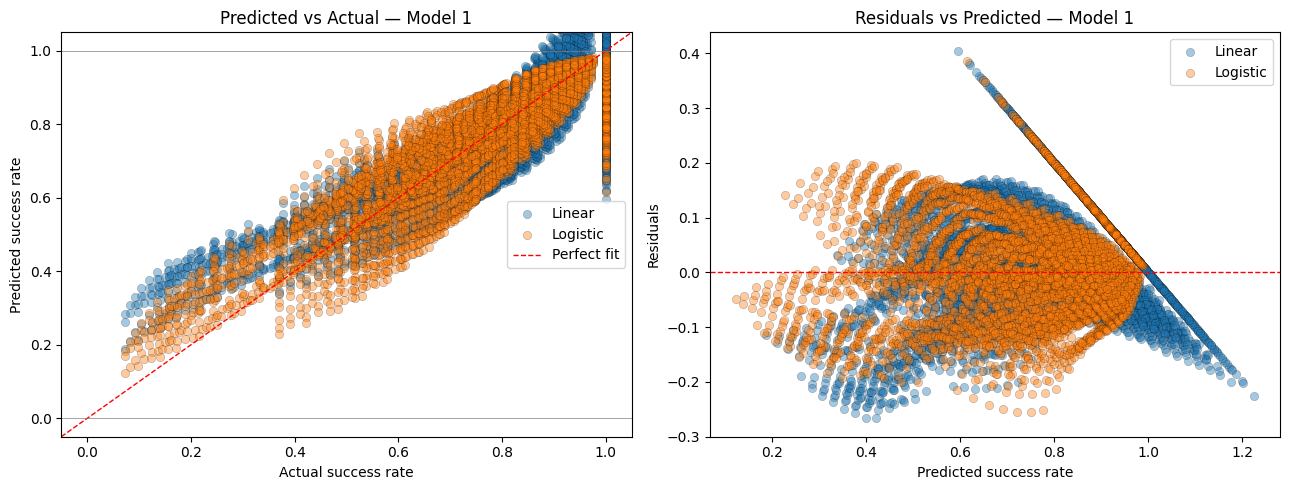

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y, y_pred1, alpha=0.4, edgecolors="k", linewidths=0.3, label="Linear")
ax.scatter(y, y_pred_logit1, alpha=0.4, edgecolors="k", linewidths=0.3,
           color="C1", label="Logistic")
lims = [-0.05, 1.05]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect fit")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axhline(1, color="gray", linewidth=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual success rate")
ax.set_ylabel("Predicted success rate")
ax.set_title("Predicted vs Actual — Model 1")
ax.legend()

ax = axes[1]
ax.scatter(y_pred1, y - y_pred1, alpha=0.4, edgecolors="k", linewidths=0.3, label="Linear")
ax.scatter(y_pred_logit1, y - y_pred_logit1, alpha=0.4, edgecolors="k",
           linewidths=0.3, color="C1", label="Logistic")
ax.axhline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted success rate")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Predicted — Model 1")
ax.legend()

plt.tight_layout()
plt.show()


## Model 2 — Position-Agnostic

Average success rate over the 5 positions before fitting. Useful when designing a deck
without knowing where you will sit.


In [30]:
FEATURES_AGNOSTIC = ["deck_size", "zillahs_in_deck", "highways_in_deck", "max_capa"]

df_agnostic = (
    df_agg
    .groupby(FEATURES_AGNOSTIC)
    .agg(
        success_rate=("success_rate", "mean"),
        successes=("successes", "sum"),
        n_simulations=("n_simulations", "sum"),
    )
    .reset_index()
)

X2 = df_agnostic[FEATURES_AGNOSTIC].to_numpy()
y2 = df_agnostic["success_rate"].to_numpy()

model2 = LinearRegression()
model2.fit(X2, y2)
y2_pred = model2.predict(X2)

print(f"Intercept: {model2.intercept_:.4f}")
coef2 = pd.DataFrame({"feature": FEATURES_AGNOSTIC, "coefficient": model2.coef_})
print(coef2.to_string(index=False))

print()
print(f"R²   (train) : {r2_score(y2, y2_pred):.4f}")
print(f"MAE  (train) : {mean_absolute_error(y2, y2_pred):.4f}")
print(f"RMSE (train) : {np.sqrt(mean_squared_error(y2, y2_pred)):.4f}")

cv_shuffled2 = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_r2_2 = cross_val_score(LinearRegression(), X2, y2, cv=cv_shuffled2, scoring="r2")
print(f"R² (5-fold CV, shuffled): {cv_r2_2.mean():.4f} ± {cv_r2_2.std():.4f}")

# Logistic counterpart
logit2 = fit_weighted_logistic(X2, df_agnostic)
y2_pred_logit = logit2.predict_proba(X2)[:, 1]
print(f"\nLogistic R² (train): {r2_score(y2, y2_pred_logit):.4f}")
print(f"Logistic predictions in [0, 1]: "
      f"{y2_pred_logit.min():.4f} to {y2_pred_logit.max():.4f}")


Intercept: 1.4085
         feature  coefficient
       deck_size    -0.004593
 zillahs_in_deck     0.028944
highways_in_deck     0.026360
        max_capa    -0.072653

R²   (train) : 0.9326
MAE  (train) : 0.0320
RMSE (train) : 0.0412
R² (5-fold CV, shuffled): 0.9312 ± 0.0064

Logistic R² (train): 0.9791
Logistic predictions in [0, 1]: 0.2373 to 0.9747


## Conclusion

### Formula reference

Blood accumulation (exact):

$$\text{blood}_{T1}(\text{pos}) = \min(4, \text{pos}) + \text{acc}_{T1}$$
$$\text{blood}_{T2}(\text{pos}) = \text{blood}_{T1}(\text{pos}) + 4 + \text{acc}_{T2}$$
$$\text{success}(\text{pos}, \text{cap}) = \mathbb{1}[\text{blood}_{T1} \ge \text{cap}] \;\vee\; \mathbb{1}[\text{blood}_{T2} \ge \text{cap}]$$

### Model 1 — Position-aware (with interaction term)

$$\hat{P} = \beta_0 + \beta_1\,\text{pos} + \beta_2\,\text{deck} + \beta_3\,\text{zillahs} + \beta_4\,\text{highways} + \beta_5\,\text{cap} + \beta_6\,(\text{pos} \times \text{cap})$$

**Note:** the coefficients reported in the previous notebook revision were obtained under
incorrect Highway semantics (its persistent +2 was missing on T2). With the fix, expect:

- The coefficient on `highways` to **increase** (Highway now contributes on both turns
  when played on T1, not just one).
- The coefficient on `zillahs` to remain roughly stable (Zillah's semantics unchanged).
- Re-run the simulation and regression to read the new values directly from the output of
  the cells above.

The CV R² of Model 1 is structurally low because the underlying success curve is a
sigmoid around `acc + min(4, pos) ≥ cap`, not a linear function. The interaction term
`pos × cap` partially absorbs this but cannot compensate for the discrete step in
`min(4, pos)` between positions 3 and 4. The `GroupKFold(by=position)` test confirms this:
extrapolation to a held-out position fails completely.

### Model 2 — Position-agnostic

$$\hat{P} = \beta_0 + \beta_1\,\text{deck} + \beta_2\,\text{zillahs} + \beta_3\,\text{highways} + \beta_4\,\text{cap}$$

Averaging across positions removes the structural non-linearity caused by discrete seat
effects. The result is a stable, well-generalising linear model. The coefficients on the
four position-independent features should be very close to those of Model 1, confirming
that the card and deck effects are cleanly separable from the seating effect.

### Logistic counterparts

The weighted logistic regression has predictions guaranteed in $[0, 1]$ and typically
matches the linear $R^2$ within a few percentage points. Its main value is **honest
extrapolation**: the linear models predict $P > 1$ for very heavy acceleration packages
(intercept = 1.5765 in the previous fit), which is meaningless in any decision context.

### Practical take-aways (qualitative — refresh after re-running)

- Zillah's Valley gives +4 on the turn played; Information Highway gives +2 every turn
  it is in play. Over a 2-turn window where both are played T1, that is 4 vs 4 — Highway
  catches up if played early.
- Zillah's is still strictly preferred when forced to choose one Master per turn, because
  it pays its full +4 immediately while Highway pays out over time.
- Deck thinning matters: every 5-card increase in library size dilutes draw probabilities
  and costs success rate — worth keeping the crypt-support package tight.
- A tree-based or polynomial model would beat both linear and logistic for per-seat
  precision; left as future work.


## Minimum Acceleration Package — Tournament-aware analysis

### From per-game probability to tournament objective

The previous design target ($P_{\text{game}} \geq 0.90$) is a **per-game** threshold and
does not reflect the structure of a real VEKN tournament: 3 games per player (2 qualifying
rounds + 1 final). What matters operationally is **how many games out of 3 the deck must
deliver the early star** for the plan to hold.

Let $p$ = probability of pulling out the star vampire on T1 or T2 in a given game, and
$X \sim \text{Binomial}(3, p)$ the number of successes over the 3 games of the tournament.
Three operational criteria, each with a confidence target of 90 %:

| Criterion | Tournament event | Formula | Required $p$ |
|---|---|---|---|
| **C1** — at least 1 game out of 3 | $P(X \geq 1) \geq 0.90$ | $1 - (1-p)^3 \geq 0.90$ | $p \geq 0.536$ |
| **C2** — at least 2 games out of 3 | $P(X \geq 2) \geq 0.90$ | $3p^2 - 2p^3 \geq 0.90$ | $p \geq 0.804$ |
| **C3** — all 3 games | $P(X = 3) \geq 0.90$ | $p^3 \geq 0.90$ | $p \geq 0.965$ |

These thresholds replace the arbitrary 90 % per-game value. C2 corresponds to a typical
"qualify with 2 GWs over 3 rounds" mindset; C1 is for decks where the early star is just a
nice-to-have; C3 is for decks where the star is a strict prerequisite to any win.

### Analytical constraint

For each criterion's threshold $p^*$, isolating the acceleration cards from **linear**
Model 2 gives a constraint in $(z, h)$ space for given deck size $d$ and capacity $c$:

$$\beta_z\,z + \beta_h\,h \;\geq\; p^* - \beta_0 - \beta_d\,d - \beta_c\,c$$

where $\beta_0, \beta_d, \beta_z, \beta_h, \beta_c$ are the Model 2 coefficients. Whenever
the right-hand side exceeds $\beta_z \cdot 16 + \beta_h \cdot 5$ (the maximum acceleration
in our parameter grid), no feasible solution exists — the cell is labelled `N/A`.

### 95 % CI on the mean prediction

The OLS confidence interval for the mean response at a new point $\mathbf{x}$:

$$\hat{P}(\mathbf{x}) \pm t_{n-p, 0.025}\,\hat{s}\,\sqrt{\mathbf{x}^\top (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{x}}$$

For each criterion we report two views: **optimistic** (use $\hat{P}$) and **conservative**
(use the CI lower bound). The conservative view is the one that protects against the
regression's residual error.


In [31]:
from scipy.optimize import brentq

# Confidence target (90 % chance of meeting the tournament objective)
CONFIDENCE_TARGET = 0.90

# Solve for the per-game p threshold corresponding to each criterion
P_THRESHOLDS = {
    "C1: ≥ 1 game / 3":  1 - (1 - CONFIDENCE_TARGET) ** (1 / 3),
    "C2: ≥ 2 games / 3": brentq(
        lambda p: 3 * p ** 2 - 2 * p ** 3 - CONFIDENCE_TARGET, 0.5, 0.999
    ),
    "C3: 3 games / 3":   CONFIDENCE_TARGET ** (1 / 3),
}

print(f"Per-game probability thresholds (confidence = {CONFIDENCE_TARGET:.0%}):")
for label, p_star in P_THRESHOLDS.items():
    print(f"  {label:<22} → p ≥ {p_star:.4f}")


Per-game probability thresholds (confidence = 90%):
  C1: ≥ 1 game / 3       → p ≥ 0.5358
  C2: ≥ 2 games / 3      → p ≥ 0.8042
  C3: 3 games / 3        → p ≥ 0.9655


In [32]:
def regression_mean_ci(
    model: LinearRegression,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_new: np.ndarray,
    alpha: float = 0.05,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """OLS confidence interval on the mean prediction.

    Uses the standard formula: ŷ ± t_{n−p, α/2} · ŝ · √(x'(X'X)⁻¹x)
    Outputs clipped to [0, 1] (probability bounds).
    """
    n, k = X_train.shape
    p = k + 1  # k features + 1 intercept

    y_hat = model.predict(X_new)
    s2 = np.sum((y_train - model.predict(X_train)) ** 2) / (n - p)

    X_aug = np.column_stack([np.ones(n), X_train])
    XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
    X_new_aug = np.column_stack([np.ones(len(X_new)), X_new])

    leverage = np.einsum("ij,jk,ik->i", X_new_aug, XtX_inv, X_new_aug)
    t_crit = sp_stats.t.ppf(1 - alpha / 2, df=n - p)
    margin = t_crit * np.sqrt(s2 * leverage)

    return y_hat, (y_hat - margin).clip(0, 1), (y_hat + margin).clip(0, 1)


# Model 2 grid (position-agnostic)
df_grid2 = pd.DataFrame([
    {"deck_size": d, "zillahs_in_deck": z, "highways_in_deck": h, "max_capa": c}
    for d in DECK_SIZES
    for z in ZILLAHS_VALLEY_COPIES
    for h in INFORMATION_HIGHWAY_COPIES
    for c in MAX_CAPA
])
yh2, cil2, cih2 = regression_mean_ci(
    model2, X2, y2, df_grid2[FEATURES_AGNOSTIC].to_numpy()
)
df_grid2["y_hat"] = yh2
df_grid2["ci_lo"] = cil2
df_grid2["ci_hi"] = cih2
df_grid2["total"] = df_grid2["zillahs_in_deck"] + df_grid2["highways_in_deck"]

# Model 1 grid (position-aware)
df_grid1 = pd.DataFrame([
    {
        "position": pos, "deck_size": d, "zillahs_in_deck": z,
        "highways_in_deck": h, "max_capa": c, "position_x_max_capa": pos * c,
    }
    for pos in POSITIONS
    for d in DECK_SIZES
    for z in ZILLAHS_VALLEY_COPIES
    for h in INFORMATION_HIGHWAY_COPIES
    for c in MAX_CAPA
])
yh1, cil1, cih1 = regression_mean_ci(model1, X, y, df_grid1[FEATURES].to_numpy())
df_grid1["y_hat"] = yh1
df_grid1["ci_lo"] = cil1
df_grid1["ci_hi"] = cih1
df_grid1["total"] = df_grid1["zillahs_in_deck"] + df_grid1["highways_in_deck"]

print(f"Model 2 — {len(df_grid2):,} grid points | "
      f"CI width: [{(cih2-cil2).min():.4f}, {(cih2-cil2).max():.4f}]")
print(f"Model 1 — {len(df_grid1):,} grid points | "
      f"CI width: [{(cih1-cil1).min():.4f}, {(cih1-cil1).max():.4f}]")


Model 2 — 980 grid points | CI width: [0.0000, 0.0158]
Model 1 — 4,900 grid points | CI width: [0.0000, 0.0205]


In [33]:
def min_package(
    df: pd.DataFrame, pred_col: str, threshold: float, group_cols: list[str]
) -> pd.DataFrame:
    """Minimum-total-card solution per group where pred_col >= threshold.

    Tie-break: prefer more Zillah's Valley (higher blood efficiency per card).
    """
    feasible = df[df[pred_col] >= threshold].copy()
    if feasible.empty:
        return feasible
    return (
        feasible
        .sort_values(
            group_cols + ["total", "zillahs_in_deck"],
            ascending=[True] * len(group_cols) + [True, False],
        )
        .groupby(group_cols, as_index=False)
        .first()
    )


G2 = ["deck_size", "max_capa"]
SHOW = ["deck_size", "max_capa", "zillahs_in_deck", "highways_in_deck",
        "total", "y_hat", "ci_lo", "ci_hi"]

# Print compact summaries for Model 2 across the 3 criteria
for label, p_star in P_THRESHOLDS.items():
    print(f"\n{'═' * 70}")
    print(f"  {label}  →  per-game p ≥ {p_star:.3f}")
    print(f"{'═' * 70}")

    m2_opt = min_package(df_grid2, "y_hat", p_star, G2)
    m2_con = min_package(df_grid2, "ci_lo", p_star, G2)

    print(f"\n  Model 2 — Optimistic ({len(m2_opt)} feasible cells / "
          f"{len(DECK_SIZES) * len(MAX_CAPA)})")
    if not m2_opt.empty:
        print(m2_opt[SHOW].round(3).to_string(index=False))
    print(f"\n  Model 2 — Conservative ({len(m2_con)} feasible cells / "
          f"{len(DECK_SIZES) * len(MAX_CAPA)})")
    if not m2_con.empty:
        print(m2_con[SHOW].round(3).to_string(index=False))



══════════════════════════════════════════════════════════════════════
  C1: ≥ 1 game / 3  →  per-game p ≥ 0.536
══════════════════════════════════════════════════════════════════════

  Model 2 — Optimistic (28 feasible cells / 28)
 deck_size  max_capa  zillahs_in_deck  highways_in_deck  total  y_hat  ci_lo  ci_hi
        60         8                4                 1      5  0.694  0.686  0.702
        60         9                4                 1      5  0.621  0.614  0.628
        60        10                4                 1      5  0.549  0.541  0.556
        60        11                6                 2      8  0.560  0.554  0.567
        65         8                4                 1      5  0.671  0.664  0.678
        65         9                4                 1      5  0.598  0.592  0.605
        65        10                4                 2      6  0.552  0.546  0.558
        65        11                6                 2      8  0.537  0.531  0.543
        70

In [34]:
ROW_VALS = list(DECK_SIZES)
COL_VALS = list(MAX_CAPA)


def _heatmap(min_df: pd.DataFrame, title: str, ax, vmax: int = 21) -> None:
    """Minimum-package heatmap. Color = total cards needed; annotation = NzZ + NhH."""
    def safe_piv(col):
        if min_df.empty:
            return pd.DataFrame(np.nan, index=ROW_VALS, columns=COL_VALS)
        return (
            min_df.pivot(index="deck_size", columns="max_capa", values=col)
            .reindex(index=ROW_VALS, columns=COL_VALS)
        )

    piv_total = safe_piv("total")
    piv_z = safe_piv("zillahs_in_deck")
    piv_h = safe_piv("highways_in_deck")
    piv_p = safe_piv("y_hat")
    piv_ci = safe_piv("ci_lo")

    cmap = plt.cm.YlGn_r.copy()
    cmap.set_bad(color="#e0e0e0")

    im = ax.imshow(
        piv_total.values.astype(float),
        cmap=cmap, aspect="auto", vmin=5, vmax=vmax,
    )

    for i, _r in enumerate(ROW_VALS):
        for j, _c in enumerate(COL_VALS):
            val = piv_total.iloc[i, j]
            if np.isnan(val):
                ax.text(j, i, "N / A", ha="center", va="center",
                        fontsize=9, color="crimson", fontweight="bold")
            else:
                z, h = int(piv_z.iloc[i, j]), int(piv_h.iloc[i, j])
                p_v, ci_v = piv_p.iloc[i, j], piv_ci.iloc[i, j]
                ax.text(j, i, f"{z}Z + {h}H\nP̂={p_v:.2f} [{ci_v:.2f}]",
                        ha="center", va="center", fontsize=7)

    ax.set_xticks(range(len(COL_VALS)))
    ax.set_xticklabels([f"cap {c}" for c in COL_VALS], fontsize=8)
    ax.set_yticks(range(len(ROW_VALS)))
    ax.set_yticklabels([f"{r} cards" for r in ROW_VALS], fontsize=8)
    ax.set_title(title, fontsize=9, pad=6)
    plt.colorbar(im, ax=ax, label="Total acc cards", shrink=0.85)


### Heatmaps — Model 2 (position-agnostic)

One row per criterion; left column = optimistic (mean prediction), right column =
conservative (95 % CI lower bound). Cells label: $N_Z$ Zillah's + $N_H$ Highway, then
predicted $\hat{P}$ and CI lower bound.


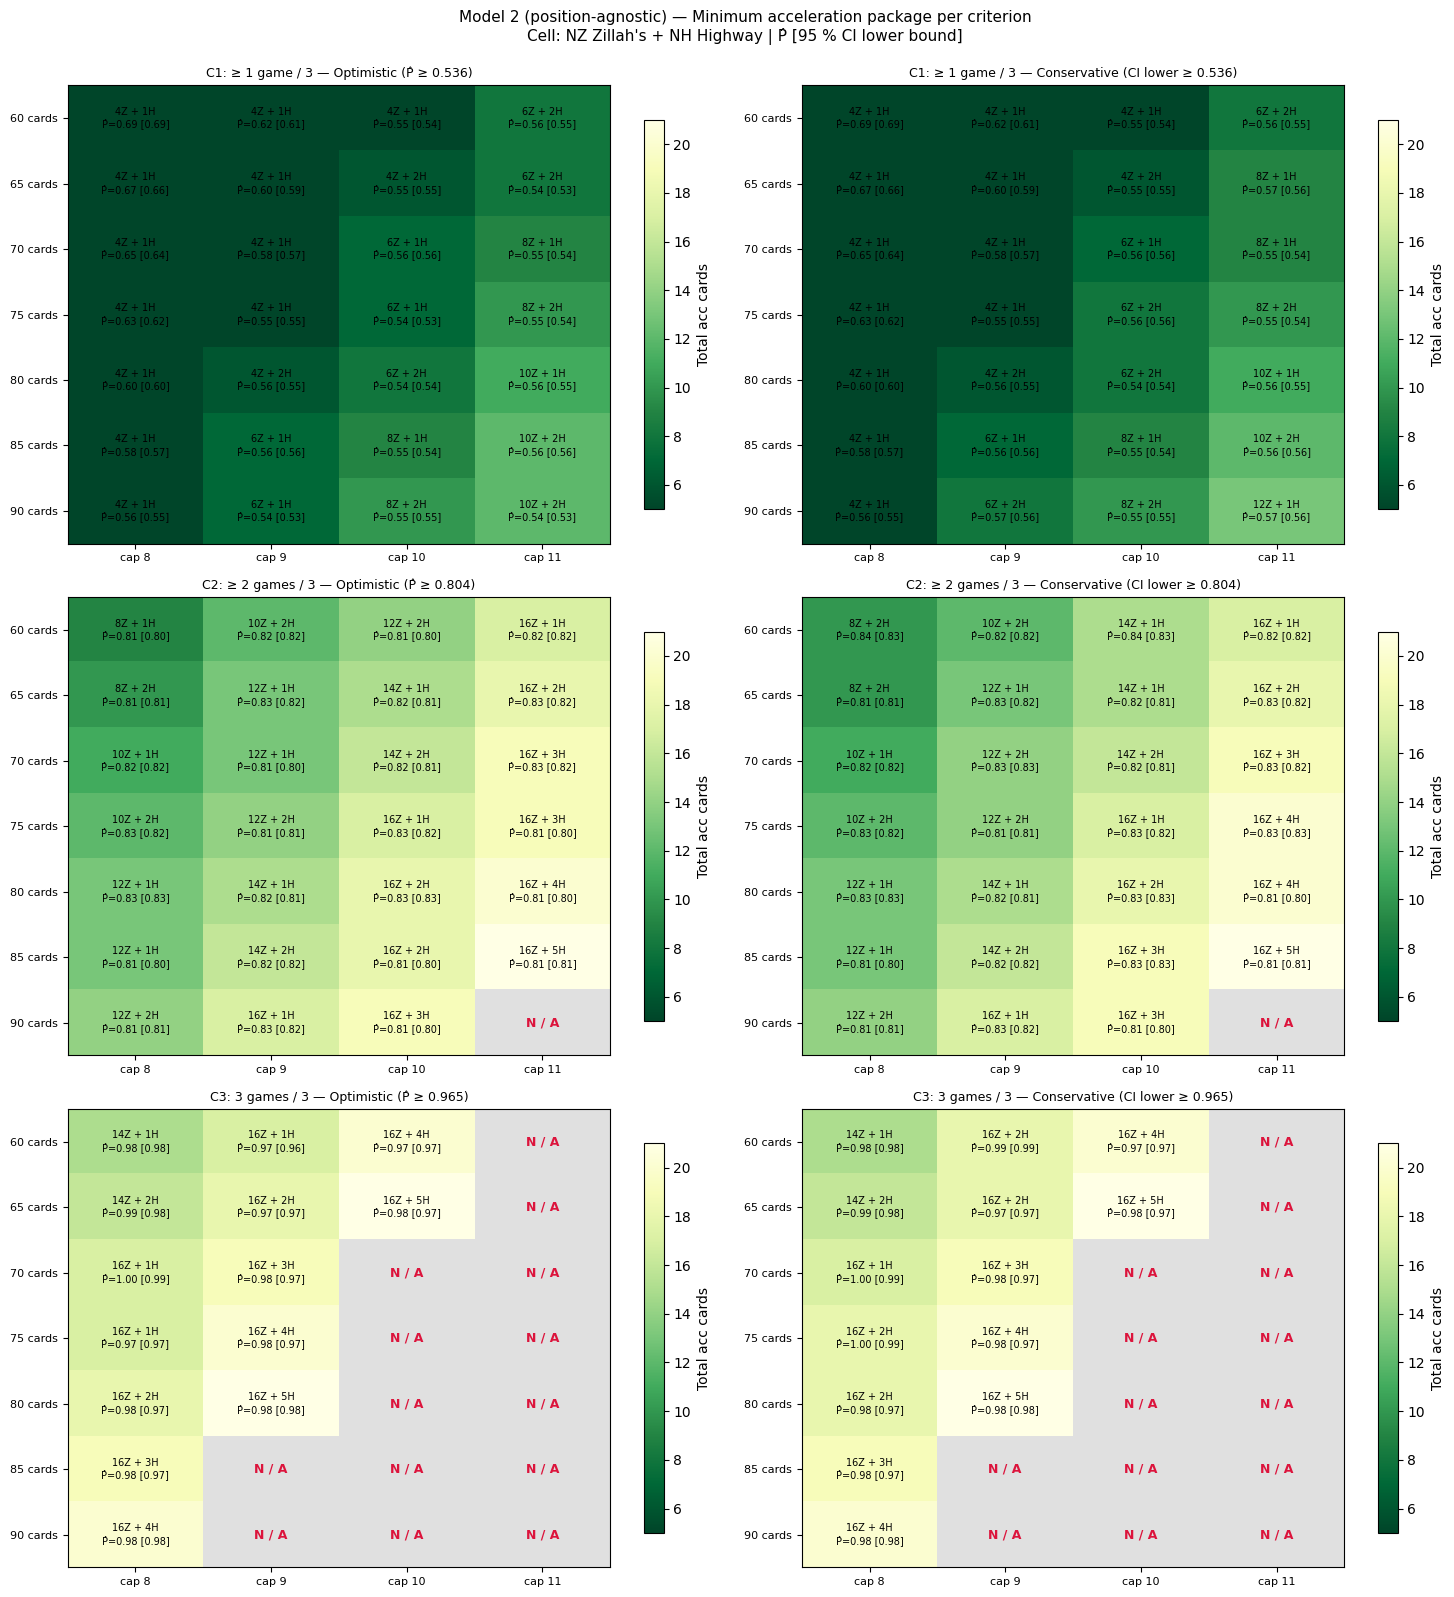

In [35]:
fig, axes = plt.subplots(3, 2, figsize=(15, 16))
fig.suptitle(
    f"Model 2 (position-agnostic) — Minimum acceleration package per criterion\n"
    f"Cell: NZ Zillah's + NH Highway | P̂ [95 % CI lower bound]",
    fontsize=11, y=0.995,
)

for row, (label, p_star) in enumerate(P_THRESHOLDS.items()):
    m2_opt = min_package(df_grid2, "y_hat", p_star, G2)
    m2_con = min_package(df_grid2, "ci_lo", p_star, G2)
    _heatmap(m2_opt, f"{label} — Optimistic (P̂ ≥ {p_star:.3f})", axes[row, 0])
    _heatmap(m2_con, f"{label} — Conservative (CI lower ≥ {p_star:.3f})", axes[row, 1])

plt.tight_layout()
plt.show()


### Heatmaps — Model 1 (position-aware)

We show the two extreme seats: position 1 (hardest — only 1 transfer at T1) and position 5
(easiest — 4 transfers at T1). The other positions interpolate between these.


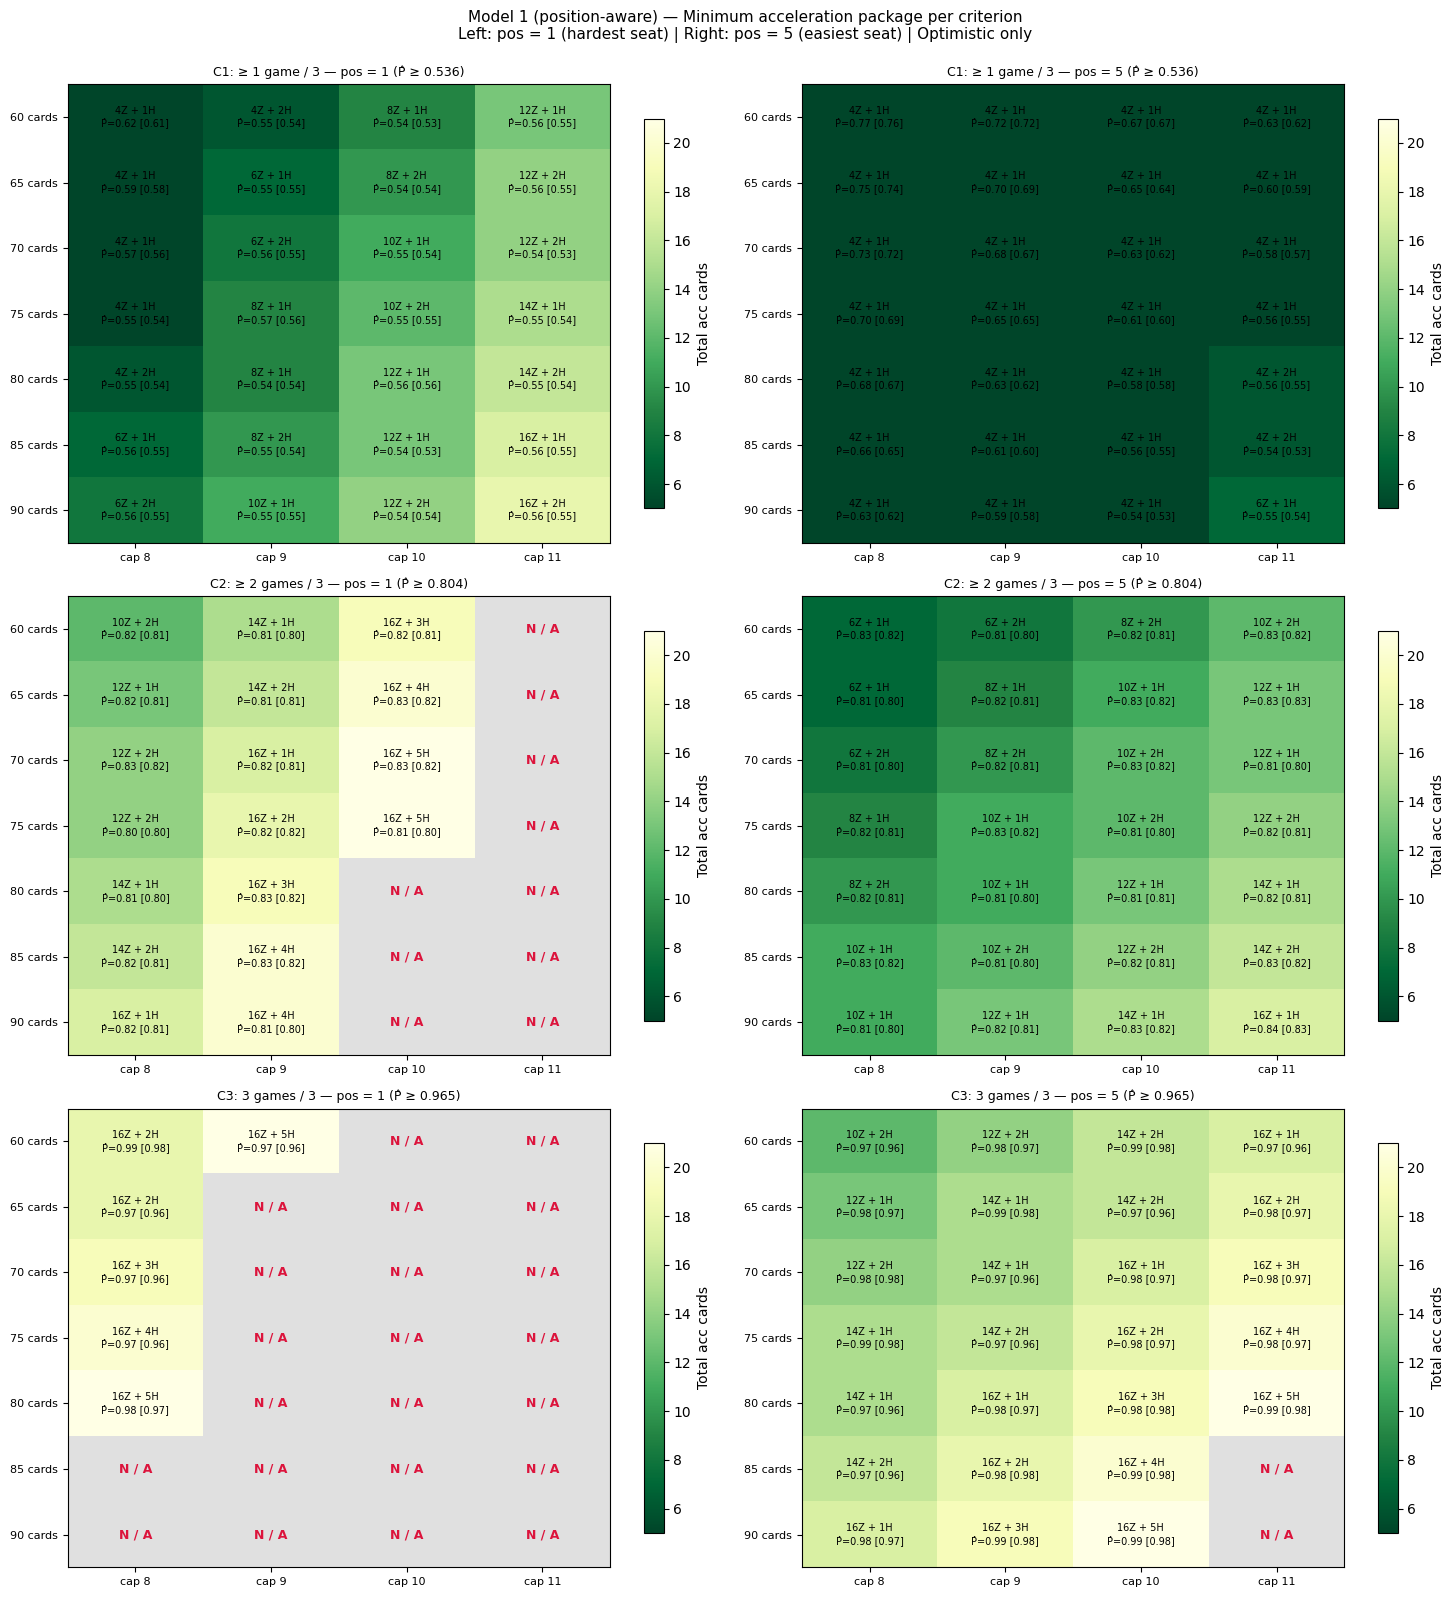

In [36]:
fig, axes = plt.subplots(3, 2, figsize=(15, 16))
fig.suptitle(
    f"Model 1 (position-aware) — Minimum acceleration package per criterion\n"
    f"Left: pos = 1 (hardest seat) | Right: pos = 5 (easiest seat) | Optimistic only",
    fontsize=11, y=0.995,
)

for row, (label, p_star) in enumerate(P_THRESHOLDS.items()):
    m1_p1 = min_package(df_grid1[df_grid1["position"] == 1], "y_hat", p_star, G2)
    m1_p5 = min_package(df_grid1[df_grid1["position"] == 5], "y_hat", p_star, G2)
    _heatmap(m1_p1, f"{label} — pos = 1 (P̂ ≥ {p_star:.3f})", axes[row, 0])
    _heatmap(m1_p5, f"{label} — pos = 5 (P̂ ≥ {p_star:.3f})", axes[row, 1])

plt.tight_layout()
plt.show()


### Reading guide

The three criteria yield very different deck-building budgets:

- **C1 (≥ 1/3 games)** is cheap — the per-game threshold $p \geq 0.54$ is reachable on
  most $(d, c)$ cells with a light splash. Choose this if the early star is **opportunistic**:
  nice when it happens, not required.

- **C2 (≥ 2/3 games)** is the **default tournament target** — the per-game threshold
  $p \geq 0.80$ matches the typical "qualify with 2 GWs" mindset. Most decks where the
  early star is **a key part of the plan but has a backup** should aim here.

- **C3 (3/3 games)** is expensive — the per-game threshold $p \geq 0.97$ may not even be
  feasible in the parameter grid for high capacities (look for `N/A` cells). Choose this
  only if the early star is a **strict prerequisite** to any win, with no plan B.

**Caveats.**

1. The binomial model assumes independence between games. This holds for the card-draw
   layer (re-shuffle between games) but ignores meta-game effects (player familiarity with
   the deck, fatigue, opposing decks varying between rounds).
2. "Pulling out the star T1–T2" is only a **proxy** for winning the game — necessary in
   many archetypes, never sufficient by itself. The actual GW depends on the full deck
   plan (combat, vote, bleed, defence) and seating dynamics.
3. The conservative criterion uses the regression's confidence interval, which is **only**
   a bound on regression error — not on the underlying simulator's modelling assumptions
   (no mulligan, no crypt influence to draw the vampire, etc., as discussed earlier).
